In [2]:
"""
Importación de librerías para el procesamiento y preparación de datos.

Librerías:
    numpy:
        Permite trabajar con arreglos y realizar operaciones numéricas.

    train_test_split:
        Permite dividir los datos en conjuntos de entrenamiento y prueba.

    StandardScaler:
        Permite estandarizar las variables numéricas para que tengan
        una media de 0 y una desviación estándar de 1.
"""

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
# =============================================================================
# CREACIÓN DEL CONJUNTO DE DATOS
# =============================================================================

# X contiene las características de las frutas.
#
# Cada fila representa una fruta y cada columna representa una característica
# caracteristicas hipoteticas:
#   - Columna 1: peso de la fruta en gramos.
#   - Columna 2: contenido de azúcar en gramos.
#   - Columna 3: grado de madurez, expresado como un valor entre 0 y 1.
#
# Las primeras 10 muestras corresponden a manzanas.
# Las siguientes 10 muestras corresponden a bananos.

X = np.array([

    # MANZANAS

    [150, 7.5, 0.10], [160, 8.0, 0.15], [145, 7.2, 0.05],
    [170, 8.3, 0.20], [155, 7.8, 0.10], [165, 8.1, 0.15],
    [140, 7.0, 0.05], [175, 8.5, 0.20], [158, 7.9, 0.10],
    [162, 8.2, 0.15],

    # BANANOS

    [120, 18.0, 0.90], [125, 19.0, 0.95], [115, 17.5, 0.85],
    [130, 20.0, 1.00], [118, 18.5, 0.90], [123, 19.5, 0.95],
    [110, 17.0, 0.80], [128, 20.5, 1.00], [121, 18.8, 0.90],
    [126, 19.2, 0.95]

], dtype=float)

# =============================================================================
# CREACIÓN DE LAS ETIQUETAS
# =============================================================================

# y contiene las etiquetas que indican la clase de cada fruta.
#
#   0 = Manzana
#   1 = Banano
#
# Se generan 10 etiquetas con valor 0 para las manzanas y
# 10 etiquetas con valor 1 para los bananos.
#
# reshape(-1, 1) convierte el arreglo en una matriz de una sola columna.
y = np.array([0]*10 + [1]*10).reshape(-1, 1)

print("X:", X.shape)
print("y:", y.shape)

X: (20, 3)
y: (20, 1)


In [ ]:
# =============================================================================
# DIVISIÓN DE LOS DATOS
# =============================================================================

# Se divide el conjunto de datos en entrenamiento (80%) y prueba (20%).
# stratify mantiene la proporción de las clases en ambos conjuntos.
# random_state permite reproducir la misma división.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# =============================================================================
# ESTANDARIZACIÓN DE LOS DATOS
# =============================================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Verificación de las dimensiones de los conjuntos resultantes.

X_train: (16, 3)
X_test: (4, 3)
y_train: (16, 1)
y_test: (4, 1)


In [ ]:
# =============================================================================
# FUNCIONES DE ACTIVACIÓN Y ERROR
# =============================================================================

# Función sigmoide utilizada para convertir los valores de salida
# en probabilidades entre 0 y 1.

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Función de pérdida que calcula el error entre las etiquetas reales
# y las probabilidades predichas por el modelo.

def calcular_error(y_real, y_predicha):
    epsilon = 1e-8
    return -np.mean(
        y_real * np.log(y_predicha + epsilon)
        + (1 - y_real) * np.log(1 - y_predicha + epsilon)
    )


In [ ]:
# =============================================================================
# INICIALIZACIÓN DEL MODELO
# =============================================================================

# Se inicializan aleatoriamente los pesos y el sesgo para comenzar
# el entrenamiento del modelo.

np.random.seed(42)
W = np.random.randn(3, 1) * 0.01
b = 0.0

# Cálculo de la salida del modelo y conversión a probabilidades
# mediante la función sigmoide.

Z = X_train @ W + b
A = sigmoid(Z)

# Visualización de los valores iniciales del modelo.
print("Pesos iniciales:")
print(W)

print("Primeras predicciones:")
print(A[:5])

print("Error inicial:", calcular_error(y_train, A))


Pesos iniciales:
[[ 0.00496714]
 [-0.00138264]
 [ 0.00647689]]
Primeras predicciones:
[[0.68875619]
 [0.69197108]
 [0.64037649]
 [0.63792584]
 [0.64583371]]
Error inicial: 0.7978991972849221


In [ ]:
# =============================================================================
# ACTUALIZACIÓN DE PESOS
# =============================================================================

# Se calculan los gradientes y se actualizan los parámetros del modelo
# mediante el descenso del gradiente.

dZ = A - y_train

dW = X_train.T @ dZ / len(X_train)
db = np.mean(dZ)

learning_rate = 0.1
W = W - learning_rate * dW
b = b - learning_rate * db

# Verificación de los parámetros actualizados.
print("Pesos actualizados:")
print(W)

print("Bias actualizado:", b)


Pesos actualizados:
[[-3.23707471]
 [ 0.06871597]
 [ 0.01894357]]
Bias actualizado: -0.016487067326535907


In [ ]:
# =============================================================================
# ENTRENAMIENTO DEL MODELO
# =============================================================================

# Se inicializan los parámetros y se establece la tasa de aprendizaje
# y el número de épocas para entrenar el modelo.

np.random.seed(42)
W = np.random.randn(3, 1) * 0.01
b = 0.0
learning_rate = 0.1
epochs = 2000

for epoch in range(epochs):

    # Propagación hacia adelante.
    Z = X_train @ W + b
    A = sigmoid(Z)

    # Cálculo del error.
    error = calcular_error(y_train, A)

    # Propagación hacia atrás para obtener los gradientes.
    dZ = A - y_train
    dW = X_train.T @ dZ / len(X_train)
    db = np.mean(dZ)

    # Actualización de los parámetros mediante descenso del gradiente.
    W = W - learning_rate * dW
    b = b - learning_rate * db

    if epoch % 400 == 0:
        print("Época:", epoch, "- Error:", round(error, 4))



Época: 0 - Error: 0.6929
Época: 400 - Error: 0.0093
Época: 800 - Error: 0.0046
Época: 1200 - Error: 0.0031
Época: 1600 - Error: 0.0023


In [ ]:
# =============================================================================
# EVALUACIÓN DEL MODELO
# =============================================================================

# Se generan las probabilidades y se convierten en predicciones de clase
# utilizando un umbral de 0.5. Finalmente, se calcula la precisión del modelo.

probabilidades = sigmoid(X_test @ W + b)
predicciones = (probabilidades >= 0.5).astype(int)
accuracy = np.mean(predicciones == y_test)

print("Probabilidades:")
print(probabilidades)

print("Predicciones:")
print(predicciones)

print("Respuestas correctas:")
print(y_test)

print("Accuracy:", accuracy)


Probabilidades:
[[5.01485422e-35]
 [2.52008260e-43]
 [1.00000000e+00]
 [1.00000000e+00]]
Predicciones:
[[0]
 [0]
 [1]
 [1]]
Respuestas correctas:
[[0]
 [0]
 [1]
 [1]]
Accuracy: 1.0


In [ ]:
# =============================================================================
# PREDICCIONES Y CLASIFICACIÓN DE UNA NUEVA FRUTA
# =============================================================================

# Se comparan las predicciones del modelo con las clases reales
# del conjunto de prueba.

for i in range(len(predicciones)):
    predicha = "MANZANA" if predicciones[i][0] == 0 else "BANANO"
    real = "MANZANA" if y_test[i][0] == 0 else "BANANO"
    print("Fruta", i + 1, "| Predicción:", predicha, "| Real:", real)


# Se crea una nueva muestra y se estandariza utilizando el scaler
# previamente ajustado con los datos de entrenamiento.

fruta_nueva = np.array([[124, 19.0, 0.94]])
fruta_nueva_escalada = scaler.transform(fruta_nueva)

# Se calcula la probabilidad y se determina la clase correspondiente.
probabilidad_nueva = sigmoid(fruta_nueva_escalada @ W + b)
resultado = "BANANO" if probabilidad_nueva[0][0] >= 0.5 else "MANZANA"

print("Probabilidad:", probabilidad_nueva[0][0])
print("La red piensa que es:", resultado)


Fruta 1 | Predicción: MANZANA | Real: MANZANA
Fruta 2 | Predicción: MANZANA | Real: MANZANA
Fruta 3 | Predicción: BANANO | Real: BANANO
Fruta 4 | Predicción: BANANO | Real: BANANO
Probabilidad: 0.9999971492435427
La red piensa que es: BANANO


In [ ]:
# =============================================================================
# LABORATORIO B: RED MULTICAPA
# =============================================================================

# Se definen las funciones de activación utilizadas por la red neuronal.
# ReLU se utiliza en la capa oculta y Sigmoide en la capa de salida.

def relu(z):
    return np.maximum(0, z)

def derivada_relu(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [ ]:
# =============================================================================
# INICIALIZACIÓN DE LA RED MULTICAPA
# =============================================================================

# Se inicializan los pesos y sesgos de la capa oculta y de la capa de salida.
# La red cuenta con 3 entradas, 4 neuronas ocultas y 1 neurona de salida.

np.random.seed(42)

W1 = np.random.randn(3, 4) * np.sqrt(2 / 3)
b1 = np.zeros((1, 4))

W2 = np.random.randn(4, 1) * np.sqrt(2 / 4)
b2 = np.zeros((1, 1))

# Verificación de las dimensiones de los pesos.
print("W1:", W1.shape)
print("W2:", W2.shape)


W1: (3, 4)
W2: (4, 1)


In [ ]:
# =============================================================================
# PROPAGACIÓN HACIA ADELANTE
# =============================================================================

# Se calculan las salidas de la capa oculta y de la capa de salida
# mediante las funciones de activación ReLU y Sigmoide.

Z1 = X_train @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)

# Verificación de resultados.
print("Salida de la capa oculta:", A1.shape)
print("Primeras probabilidades:")
print(A2[:5])


Salida de la capa oculta: (16, 4)
Primeras probabilidades:
[[0.42911408]
 [0.41367727]
 [0.35607532]
 [0.34175424]
 [0.27437375]]


In [ ]:
# =============================================================================
# RETROPROPAGACIÓN
# =============================================================================

# Se calculan los gradientes de la capa de salida y se transmite
# la señal de corrección hacia la capa oculta.

m = len(X_train)

# Gradientes de la capa de salida.
dZ2 = A2 - y_train
dW2 = A1.T @ dZ2 / m
db2 = np.mean(dZ2, axis=0, keepdims=True)

# Gradientes de la capa oculta.
dA1 = dZ2 @ W2.T
dZ1 = dA1 * derivada_relu(Z1)
dW1 = X_train.T @ dZ1 / m
db1 = np.mean(dZ1, axis=0, keepdims=True)



In [ ]:
# =============================================================================
# ENTRENAMIENTO DE LA RED MULTICAPA
# =============================================================================

# Se inicializan nuevamente los parámetros y se establece la tasa
# de aprendizaje y el número de épocas.

np.random.seed(42)
W1 = np.random.randn(3, 4) * np.sqrt(2 / 3)
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * np.sqrt(2 / 4)
b2 = np.zeros((1, 1))

learning_rate = 0.05
epochs = 3000

for epoch in range(epochs):

    # Propagación hacia adelante.
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # Cálculo del error.
    error = calcular_error(y_train, A2)

    # Retropropagación.
    m = len(X_train)
    dZ2 = A2 - y_train
    dW2 = A1.T @ dZ2 / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * derivada_relu(Z1)
    dW1 = X_train.T @ dZ1 / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    # Actualización de los pesos y sesgos.
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    # Se muestra el error periódicamente durante el entrenamiento.
    if epoch % 500 == 0:
        print("Época:", epoch, "- Error:", round(error, 4))


Época: 0 - Error: 0.9529
Época: 500 - Error: 0.0555
Época: 1000 - Error: 0.0259
Época: 1500 - Error: 0.0166
Época: 2000 - Error: 0.0122
Época: 2500 - Error: 0.0096


In [ ]:
# =============================================================================
# EVALUACIÓN DE LA RED MULTICAPA
# =============================================================================

# Se realiza la propagación hacia adelante con los datos de prueba
# para obtener las probabilidades y evaluar el rendimiento del modelo.

Z1_test = X_test @ W1 + b1
A1_test = relu(Z1_test)
Z2_test = A1_test @ W2 + b2
probabilidades_test = sigmoid(Z2_test)

# Se convierten las probabilidades en predicciones usando un umbral de 0.5.
predicciones_multicapa = (probabilidades_test >= 0.5).astype(int)

# Cálculo de la precisión del modelo.
accuracy_multicapa = np.mean(predicciones_multicapa == y_test)

print("Probabilidades:")
print(probabilidades_test)

print("Predicciones:")
print(predicciones_multicapa)

print("Accuracy:", accuracy_multicapa)


Probabilidades:
[[1.42439384e-02]
 [2.06256532e-05]
 [9.85087119e-01]
 [9.85087119e-01]]
Predicciones:
[[0]
 [0]
 [1]
 [1]]
Accuracy: 1.0


In [ ]:
# =============================================================================
# LABORATORIO C: TENSORFLOW + KERAS
# =============================================================================

# Se construye la misma arquitectura de red multicapa utilizada con NumPy:
# 3 características de entrada, 4 neuronas en la capa oculta y 1 neurona de salida.

import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

modelo = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

# Muestra la estructura y cantidad de parámetros del modelo.
modelo.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =============================================================================
# CONFIGURACIÓN DEL MODELO
# =============================================================================

# Se configura el modelo indicando el optimizador, la función de pérdida
# y la métrica que se utilizará para evaluar su rendimiento.

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
# =============================================================================
# ENTRENAMIENTO DEL MODELO
# =============================================================================

# Se entrena el modelo utilizando los datos de entrenamiento durante
# 200 épocas y se almacena el historial del proceso.

historial = modelo.fit(
    X_train,
    y_train,
    epochs=200,
    verbose=0
)

# Se comparan el error inicial y el error final del entrenamiento.
print("Error inicial:", historial.history["loss"][0])
print("Error final:", historial.history["loss"][-1])


Error inicial: 0.6488346457481384
Error final: 0.0033686007373034954


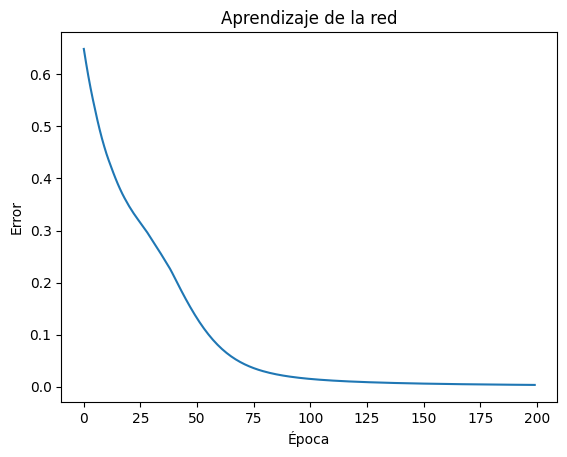

Error en prueba: 0.010526763275265694
Accuracy: 1.0


In [ ]:
# =============================================================================
# EVALUACIÓN DEL MODELO
# =============================================================================

# Se visualiza la evolución del error durante el entrenamiento y
# posteriormente se evalúa el modelo utilizando los datos de prueba.

import matplotlib.pyplot as plt

plt.plot(historial.history["loss"])
plt.title("Aprendizaje de la red")
plt.xlabel("Época")
plt.ylabel("Error")
plt.show()

# Evaluación del modelo con el conjunto de prueba.
test_loss, test_accuracy = modelo.evaluate(X_test, y_test, verbose=0)

print("Error en prueba:", test_loss)
print("Accuracy:", test_accuracy)


In [ ]:
# =============================================================================
# CLASIFICACIÓN DE UNA NUEVA FRUTA
# =============================================================================

# Se procesa una nueva muestra y se utiliza el modelo entrenado
# para obtener su probabilidad y clasificación.

fruta_nueva = np.array([[124, 19.0, 0.94]])
fruta_nueva_escalada = scaler.transform(fruta_nueva)

probabilidad = modelo.predict(fruta_nueva_escalada, verbose=0)
resultado = "BANANO" if probabilidad[0][0] >= 0.5 else "MANZANA"

print("Probabilidad:", probabilidad[0][0])
print("La red piensa que es:", resultado)


Probabilidad: 0.99551105
La red piensa que es: BANANO


In [ ]:
# =============================================================================
# CONJUNTO DE DATOS MULTICLASE
# =============================================================================

# Se crea un nuevo conjunto de datos con tres clases de frutas:
# manzanas (0), bananos (1) y naranjas (2).
# Cada muestra contiene tres características.

X_multi = np.array([
    # MANZANAS - 0
    [150,7.5,.10],[160,8.0,.15],[145,7.2,.05],[170,8.3,.20],[155,7.8,.10],
    [165,8.1,.15],[140,7.0,.05],[175,8.5,.20],[158,7.9,.10],[162,8.2,.15],

    # BANANOS - 1
    [120,18.0,.90],[125,19.0,.95],[115,17.5,.85],[130,20.0,1.00],[118,18.5,.90],
    [123,19.5,.95],[110,17.0,.80],[128,20.5,1.00],[121,18.8,.90],[126,19.2,.95],

    # NARANJAS - 2
    [180,8.0,.35],[190,8.5,.40],[175,7.8,.30],[200,9.0,.45],[185,8.2,.35],
    [195,8.7,.40],[170,7.5,.30],[205,9.2,.45],[188,8.4,.35],[192,8.6,.40]
], dtype=float)

# Se crean las etiquetas correspondientes a cada clase:
# 0 = Manzana, 1 = Banano, 2 = Naranja.

y_multi = np.array([0]*10 + [1]*10 + [2]*10)


In [ ]:
# =============================================================================
# DIVISIÓN Y ESTANDARIZACIÓN DE LOS DATOS MULTICLASE
# =============================================================================

# Se dividen los datos en conjuntos de entrenamiento y prueba,
# manteniendo la proporción de cada clase.

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

# Se estandarizan las características para facilitar el entrenamiento
# del modelo.

scaler_multi = StandardScaler()
X_train_multi = scaler_multi.fit_transform(X_train_multi)
X_test_multi = scaler_multi.transform(X_test_multi)


In [ ]:
# =============================================================================
# CONSTRUCCIÓN Y CONFIGURACIÓN DEL MODELO MULTICLASE
# =============================================================================

# Se construye una red neuronal para clasificar las tres clases de frutas.
# La arquitectura utiliza 3 entradas, 6 neuronas ocultas y 3 salidas.

tf.random.set_seed(42)

modelo_multi = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(6, activation="relu"),
    keras.layers.Dense(3, activation="softmax")
])

# Se configura el modelo utilizando Adam como optimizador y
# sparse_categorical_crossentropy como función de pérdida.

modelo_multi.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
# =============================================================================
# ENTRENAMIENTO Y EVALUACIÓN DEL MODELO MULTICLASE
# =============================================================================

# Se entrena el modelo con los datos de entrenamiento y posteriormente
# se evalúa utilizando el conjunto de prueba.

historial_multi = modelo_multi.fit(
    X_train_multi,
    y_train_multi,
    epochs=300,
    verbose=0
)

loss_multi, accuracy_multi = modelo_multi.evaluate(
    X_test_multi,
    y_test_multi,
    verbose=0
)

# Se obtienen las probabilidades y se selecciona la clase con mayor
# probabilidad como predicción final.

probabilidades_multi = modelo_multi.predict(X_test_multi, verbose=0)
predicciones_multi = np.argmax(probabilidades_multi, axis=1)

print("Accuracy:", accuracy_multi)
print("Predicciones:", predicciones_multi)
print("Reales:", y_test_multi)


# =============================================================================
# CLASIFICACIÓN DE UNA NUEVA FRUTA
# =============================================================================

# Se utiliza una nueva muestra para comprobar la capacidad del modelo
# de identificar una fruta entre las tres clases.

nombres_frutas = ["MANZANA", "BANANO", "NARANJA"]

fruta_nueva_multi = np.array([[190, 8.5, 0.38]])
fruta_nueva_multi = scaler_multi.transform(fruta_nueva_multi)

prob = modelo_multi.predict(fruta_nueva_multi, verbose=0)
clase = np.argmax(prob, axis=1)[0]

print("La red piensa que es:", nombres_frutas[clase])


Accuracy: 1.0
Predicciones: [2 1 2 0 1 0]
Reales: [2 1 2 0 1 0]
La red piensa que es: NARANJA


In [ ]:
# =============================================================================
# LABORATORIO E: MNIST CON TENSORFLOW + KERAS
# =============================================================================

# Se carga el conjunto de datos MNIST, utilizado para clasificar imágenes
# de dígitos escritos a mano en 10 clases, correspondientes a los números
# del 0 al 9.

from tensorflow import keras
import numpy as np

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = \
    keras.datasets.mnist.load_data()

# Se verifican las dimensiones de los conjuntos de entrenamiento y prueba.
print("Entrenamiento:", x_train_mnist.shape, y_train_mnist.shape)
print("Prueba:", x_test_mnist.shape, y_test_mnist.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenamiento: (60000, 28, 28) (60000,)
Prueba: (10000, 28, 28) (10000,)


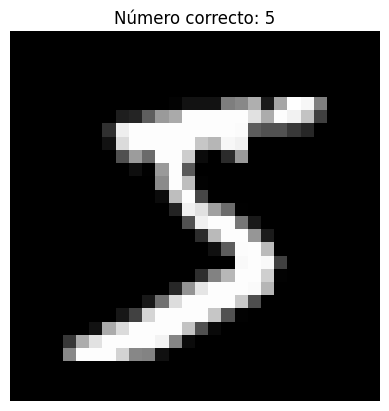

Mínimo: 0.0
Máximo: 1.0


In [ ]:
# =============================================================================
# VISUALIZACIÓN Y NORMALIZACIÓN DE LAS IMÁGENES
# =============================================================================

# Se muestra una imagen del conjunto de entrenamiento junto con su etiqueta
# para comprobar visualmente el contenido de los datos.

import matplotlib.pyplot as plt

plt.imshow(x_train_mnist[0], cmap="gray")
plt.title(f"Número correcto: {y_train_mnist[0]}")
plt.axis("off")
plt.show()

# Se normalizan los valores de los píxeles al rango [0, 1]
# para facilitar el entrenamiento de la red neuronal.

x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist = x_test_mnist.astype("float32") / 255.0

# Se comprueba el rango de los valores después de la normalización.
print("Mínimo:", x_train_mnist.min())
print("Máximo:", x_train_mnist.max())


In [ ]:
# =============================================================================
# CONSTRUCCIÓN DE LA RED NEURONAL PARA MNIST
# =============================================================================

# Se construye una red neuronal densa para clasificar los dígitos del 0 al 9.
# La arquitectura utiliza las imágenes de 28x28 píxeles como entrada,
# una capa oculta de 128 neuronas y una capa de salida de 10 clases.

import tensorflow as tf

tf.random.set_seed(42)

modelo_mnist = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

# Se muestra la estructura y los parámetros del modelo.
modelo_mnist.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =============================================================================
# CONFIGURACIÓN Y ENTRENAMIENTO DEL MODELO MNIST
# =============================================================================

# Se configura el modelo con Adam como optimizador y una función de pérdida
# adecuada para la clasificación de las 10 clases.

modelo_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Se entrena el modelo durante 5 épocas y se utiliza el 10% de los datos
# de entrenamiento para validar el aprendizaje.

historial_mnist = modelo_mnist.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9212 - loss: 0.2760 - val_accuracy: 0.9652 - val_loss: 0.1249
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9635 - loss: 0.1216 - val_accuracy: 0.9733 - val_loss: 0.0964
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9758 - loss: 0.0819 - val_accuracy: 0.9738 - val_loss: 0.0897
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9822 - loss: 0.0601 - val_accuracy: 0.9730 - val_loss: 0.0910
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9874 - loss: 0.0452 - val_accuracy: 0.9715 - val_loss: 0.0933


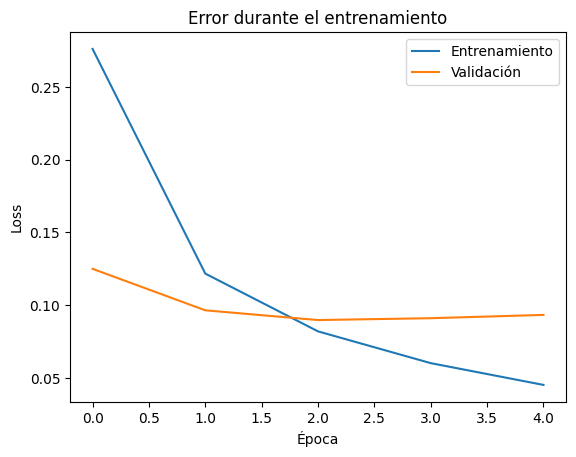

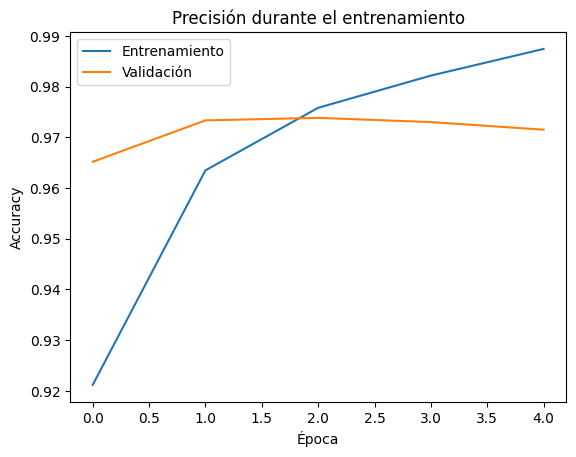

In [ ]:
# =============================================================================
# VISUALIZACIÓN DEL ENTRENAMIENTO
# =============================================================================

# Se grafican el error y la precisión del modelo durante el entrenamiento
# para observar cómo evoluciona su aprendizaje.

plt.plot(historial_mnist.history["loss"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_loss"], label="Validación")
plt.title("Error durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(historial_mnist.history["accuracy"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_accuracy"], label="Validación")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Cantidad de errores: 293


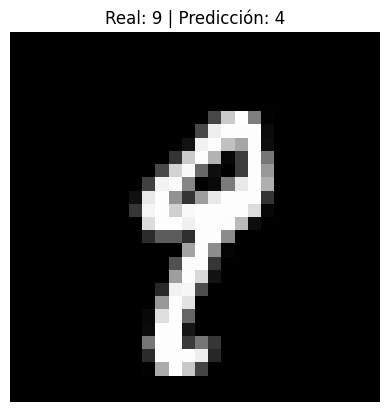

In [ ]:
# =============================================================================
# ANÁLISIS DE ERRORES DEL MODELO
# =============================================================================

# Se obtienen las predicciones del conjunto de prueba y se identifican
# las imágenes que fueron clasificadas incorrectamente.

predicciones_todas = modelo_mnist.predict(x_test_mnist, verbose=0)
clases_predichas = np.argmax(predicciones_todas, axis=1)
errores = np.where(clases_predichas != y_test_mnist)[0]

print("Cantidad de errores:", len(errores))

# Se muestra una de las imágenes clasificadas incorrectamente,
# comparando su etiqueta real con la predicción del modelo.

indice_error = errores[0]

plt.imshow(x_test_mnist[indice_error], cmap="gray")
plt.title(
    f"Real: {y_test_mnist[indice_error]} | "
    f"Predicción: {clases_predichas[indice_error]}"
)
plt.axis("off")
plt.show()


In [ ]:
# =============================================================================
# LABORATORIO F: MNIST CON PYTORCH
# =============================================================================

# Se cargan las librerías necesarias y se prepara el conjunto MNIST
# para trabajar con imágenes de dígitos escritos a mano.

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Se convierten las imágenes a tensores y se normalizan sus valores.
transform = transforms.ToTensor()

# Se carga el conjunto de entrenamiento.
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Se carga el conjunto de prueba.
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 458kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.86MB/s]


In [ ]:
# =============================================================================
# PREPARACIÓN DE LOS DATOS
# =============================================================================

# Se crean los DataLoader para organizar los datos en lotes durante
# el entrenamiento y la evaluación del modelo.

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


In [ ]:
# =============================================================================
# CONSTRUCCIÓN DE LA RED NEURONAL
# =============================================================================

# Se define una red neuronal para clasificar los dígitos de MNIST.
# La arquitectura es 784 entradas, 128 neuronas ocultas y 10 salidas.

class RedMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.capa1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.salida = nn.Linear(128, 10)

    def forward(self, x):
        # Se realiza la propagación hacia adelante de los datos.
        x = self.flatten(x)
        x = self.capa1(x)
        x = self.relu(x)
        x = self.salida(x)
        return x


# Se crea una instancia del modelo.
modelo_pytorch = RedMNIST()

print(modelo_pytorch)


RedMNIST(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (capa1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (salida): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# =============================================================================
# CONFIGURACIÓN DEL ENTRENAMIENTO
# =============================================================================

# Se define la función de pérdida y el optimizador que se utilizarán
# durante el entrenamiento de la red.

criterio = nn.CrossEntropyLoss()

optimizador = optim.Adam(
    modelo_pytorch.parameters(),
    lr=0.001
)

print("Modelo, criterio y optimizador listos")


Modelo, criterio y optimizador listos


In [ ]:
# =============================================================================
# ENTRENAMIENTO DE LA RED CON PYTORCH
# =============================================================================

# Se entrena el modelo durante varias épocas utilizando el ciclo de
# entrenamiento explícito de PyTorch.

epochs = 3

for epoch in range(epochs):
    modelo_pytorch.train()
    error_total = 0

    for imagenes, etiquetas in train_loader:

        # Se limpian los gradientes del paso anterior.
        optimizador.zero_grad()

        # Propagación hacia adelante.
        salidas = modelo_pytorch(imagenes)

        # Cálculo del error.
        error = criterio(salidas, etiquetas)

        # Retropropagación.
        error.backward()

        # Actualización de los pesos.
        optimizador.step()

        error_total += error.item()

    # Se calcula el error promedio de la época.
    promedio_error = error_total / len(train_loader)

    print(
        "Época:", epoch + 1,
        "- Error:", round(promedio_error, 4)
    )


Época: 1 - Error: 0.3403
Época: 2 - Error: 0.1541
Época: 3 - Error: 0.1074


In [ ]:
# =============================================================================
# EVALUACIÓN DEL MODELO
# =============================================================================

# Se evalúa el modelo utilizando el conjunto de prueba y se calcula
# la precisión de las predicciones.

modelo_pytorch.eval()
correctas = 0
total = 0

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        salidas = modelo_pytorch(imagenes)
        _, predicciones = torch.max(salidas, 1)

        total += etiquetas.size(0)
        correctas += (predicciones == etiquetas).sum().item()

# Se calcula la precisión final del modelo.
accuracy_pytorch = correctas / total

print("Accuracy en prueba:", accuracy_pytorch)


Accuracy en prueba: 0.9688


Número real: 7
Número predicho: 7


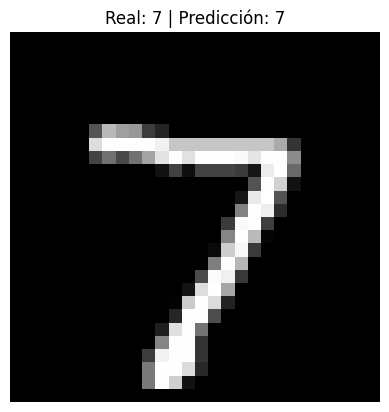

In [ ]:
# =============================================================================
# PREDICCIÓN DE UNA IMAGEN
# =============================================================================

# Se selecciona una imagen del conjunto de prueba y se utiliza el modelo
# para obtener la predicción del dígito.

imagen, etiqueta_real = test_dataset[0]
entrada = imagen.unsqueeze(0)

modelo_pytorch.eval()

with torch.no_grad():
    salida = modelo_pytorch(entrada)
    prediccion = torch.argmax(salida, dim=1).item()

print("Número real:", etiqueta_real)
print("Número predicho:", prediccion)

# Se muestra la imagen junto con su etiqueta real y la predicción del modelo.
plt.imshow(imagen.squeeze(), cmap="gray")
plt.title(f"Real: {etiqueta_real} | Predicción: {prediccion}")
plt.axis("off")
plt.show()
